# Imports

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_absolute_percentage_error

from prophet import Prophet
import lightgbm as lgb

from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, AutoETS

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)

results = {}

# Data Loading

In [4]:
train = pd.read_csv('../data/raw/train.csv', parse_dates=['Date'])
store = pd.read_csv('../data/raw/store.csv')

df = train.merge(store, on='Store', how='left')
df = df[(df['Open'] == 1) & (df['Sales'] > 0)].copy()

# Store 1 only
store_id = 1
df_store = df[df['Store'] == store_id].sort_values('Date').copy()

# Train / test split
cutoff = df_store['Date'].max() - pd.Timedelta(weeks=6)
train_s = df_store[df_store['Date'] <= cutoff].copy()
test_s  = df_store[df_store['Date'] > cutoff].copy()

print(f"Train: {len(train_s)} days | Test: {len(test_s)} days")

Train: 745 days | Test: 36 days


# Prophet

## Data Preparation & Train/Test Split

- Prophet expects two columns: ds (date) and y (value)
- Training is performed on log(sales) as decided after EDA (notebook 1)

In [5]:
prophet_train = train_s[['Date', 'Sales']].rename(columns={'Date': 'ds', 'Sales': 'y'})
prophet_train['y'] = np.log1p(prophet_train['y'])

prophet_test = test_s[['Date', 'Sales']].rename(columns={'Date': 'ds', 'Sales': 'y'})

print("Prophet expected format:")
prophet_train.head(5)

Prophet expected format:


,ds,y
1014980,2013-01-02,8.618124
1013865,2013-01-03,8.372861
1012750,2013-01-04,8.408940
1011635,2013-01-05,8.516793
1009405,2013-01-07,8.878637


## Training

In [6]:
model_prophet = Prophet(
    seasonality_mode='multiplicative',  # good for log-normal data
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
)

# Add promo as external regressor (insight from EDA in notebook 1)
prophet_train['promo'] = train_s['Promo'].values
model_prophet.add_regressor('promo')

model_prophet.fit(prophet_train)
print("Prophet trained ✓")

16:51:59 - cmdstanpy - INFO - Chain [1] start processing
16:51:59 - cmdstanpy - INFO - Chain [1] done processing


Prophet trained ✓


## Predictions

In [7]:
# Test data preparation
future = prophet_test[['ds']].copy()
future['promo'] = test_s['Promo'].values

# Predictions
forecast = model_prophet.predict(future)

# Use exp fonction to transform log(sales) back to sales
y_pred_prophet = np.expm1(forecast['yhat'].values)
y_true = test_s['Sales'].values

mape_prophet = mean_absolute_percentage_error(y_true, y_pred_prophet) * 100
results['Prophet'] = round(mape_prophet, 2)

print(f"Prophet MAPE : {mape_prophet:.1f}%")
print(f"Improvement vs baseline : {17.3 - mape_prophet:.1f} points")

Prophet MAPE : 7.3%
Improvement vs baseline : 10.0 points


## Visualization

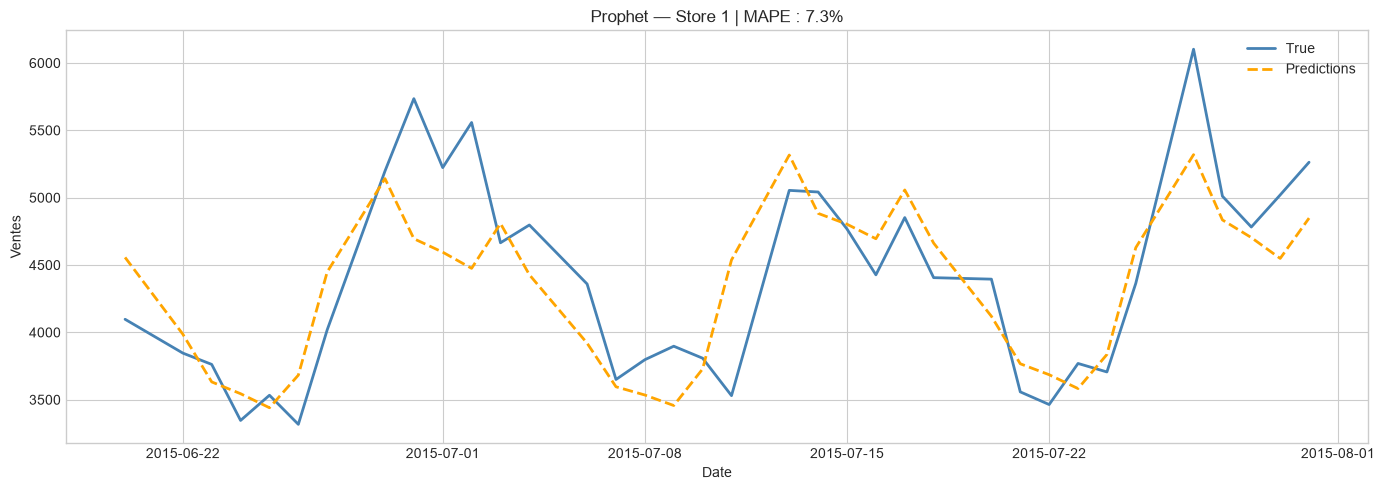

In [8]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(test_s['Date'].values, y_true, label='True', color='steelblue', linewidth=2)
ax.plot(test_s['Date'].values, y_pred_prophet, label='Predictions', 
        color='orange', linewidth=2, linestyle='--')

ax.set_title(f'Prophet — Store {store_id} | MAPE : {mape_prophet:.1f}%')
ax.set_xlabel('Date')
ax.set_ylabel('Ventes')
ax.legend()
plt.tight_layout()
plt.show()

# LightGBM

## Feature Engineering

In [9]:
def make_features(df):
    df = df.copy()

    # Time-related features
    df['year'] = df['Date'].dt.year
    df['month'] = df['Date'].dt.month
    df['day'] = df['Date'].dt.day
    df['dayofweek'] = df['Date'].dt.dayofweek
    df['weekofyear'] = df['Date'].dt.isocalendar().week.astype(int)
    df['quarter'] = df['Date'].dt.quarter
    df['is_weekend'] = (df['Date'].dt.dayofweek >= 5).astype(int)
    df['is_month_start'] = df['Date'].dt.is_month_start.astype(int)
    df['is_month_end'] = df['Date'].dt.is_month_end.astype(int)

    # Lag
    df['lag_7'] = df['Sales'].shift(7)
    df['lag_14'] = df['Sales'].shift(14)
    df['lag_28'] = df['Sales'].shift(28)

    # Moving averages
    df['rolling_mean_7'] = df['Sales'].shift(1).rolling(7).mean()
    df['rolling_mean_28'] = df['Sales'].shift(1).rolling(28).mean()
    df['rolling_std_7'] = df['Sales'].shift(1).rolling(7).std()

    # Sales-to-average ratio
    df['sales_vs_rolling'] = df['Sales'] / (df['rolling_mean_7'] + 1)

    # Store
    df['Promo'] = df['Promo'].astype(int)
    df['StateHoliday'] = df['StateHoliday'].map({'0': 0, 'a': 1, 'b': 2, 'c': 3}).fillna(0)
    df['StoreType'] = df['StoreType'].map({'a': 0, 'b': 1, 'c': 2, 'd': 3})
    df['Assortment'] = df['Assortment'].map({'a': 0, 'b': 1, 'c': 2})

    return df

print(f"Shape before feature engineering : {df_store.shape}")
df_feat = make_features(df_store)

# Remove columns with mostly NaN values
df_feat.drop(['Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval'], axis=1, inplace=True)

# Remove NaN rows (created by adding the lags)
df_feat = df_feat.dropna()

print(f"Shape after feature engineering : {df_feat.shape}")
print(f"Features : {df_feat.shape[1]} columns")
df_feat.head(5)


Shape before feature engineering : (781, 18)
Shape after feature engineering : (753, 31)
Features : 31 columns


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,year,month,day,dayofweek,weekofyear,quarter,is_weekend,is_month_start,is_month_end,lag_7,lag_14,lag_28,rolling_mean_7,rolling_mean_28,rolling_std_7,sales_vs_rolling
978185,1,1,2013-02-04,7032,762,1,1,0.0,0,2,0,1270.0,9.0,2008.0,0,2013,2,4,0,6,1,0,0,0,5598.0,4127.0,5530.0,4898.714286,5001.214286,855.366727,1.435186
977070,1,2,2013-02-05,6049,678,1,1,0.0,0,2,0,1270.0,9.0,2008.0,0,2013,2,5,1,6,1,0,0,0,4055.0,5182.0,4327.0,5103.571429,5054.857143,1166.051436,1.185016
975955,1,3,2013-02-06,6140,693,1,1,0.0,0,2,0,1270.0,9.0,2008.0,0,2013,2,6,2,6,1,0,0,0,3725.0,5394.0,4486.0,5388.428571,5116.357143,1109.382990,1.139267
974840,1,4,2013-02-07,5499,675,1,1,0.0,0,2,0,1270.0,9.0,2008.0,0,2013,2,7,3,6,1,0,0,0,4601.0,5720.0,4997.0,5733.428571,5175.428571,851.378658,0.958945
973725,1,5,2013-02-08,5681,630,1,1,0.0,0,2,0,1270.0,9.0,2008.0,0,2013,2,8,4,6,1,0,0,0,4709.0,5578.0,7176.0,5861.714286,5193.357143,707.864797,0.969005


## Train/test Split

In [10]:
FEATURES = [
    # Temporelles
    'year', 'month', 'day', 'dayofweek', 'weekofyear', 'quarter',
    'is_weekend', 'is_month_start', 'is_month_end',
    # Lags
    'lag_7', 'lag_14', 'lag_28',
    # Moyennes mobiles
    'rolling_mean_7', 'rolling_mean_28', 'rolling_std_7', 'sales_vs_rolling',
    # Store
    'Promo', 'StateHoliday', 'StoreType', 'Assortment',
    'CompetitionDistance',
]

TARGET = 'Sales'

# Same cutoff date
cutoff = df_feat['Date'].max() - pd.Timedelta(weeks=6)
train_lgb = df_feat[df_feat['Date'] <= cutoff].copy()
test_lgb  = df_feat[df_feat['Date'] > cutoff].copy()

X_train = train_lgb[FEATURES]
y_train = np.log1p(train_lgb[TARGET])  # log transform

X_test  = test_lgb[FEATURES]
y_test  = test_lgb[TARGET].values

print(f"Train : {X_train.shape} | Test : {X_test.shape}")
print(f"Features selected : {len(FEATURES)}")

Train : (717, 21) | Test : (36, 21)
Features selected : 21


## Training

In [11]:
model_lgb = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1,
)

model_lgb.fit(
    X_train, y_train,
    eval_set=[(X_test, np.log1p(y_test))],
    callbacks=[lgb.early_stopping(50, verbose=False),
               lgb.log_evaluation(100)]
)

print(f"Optimal number of estimators : {model_lgb.best_iteration_}")

[100]	valid_0's l2: 0.000431855
[200]	valid_0's l2: 0.000389628
Optimal number of estimators : 197


## Predictions & Metrics

LightGBM MAPE : 1.7%
Prophet MAPE  : 7.33%
Baseline MAPE : 17.3%


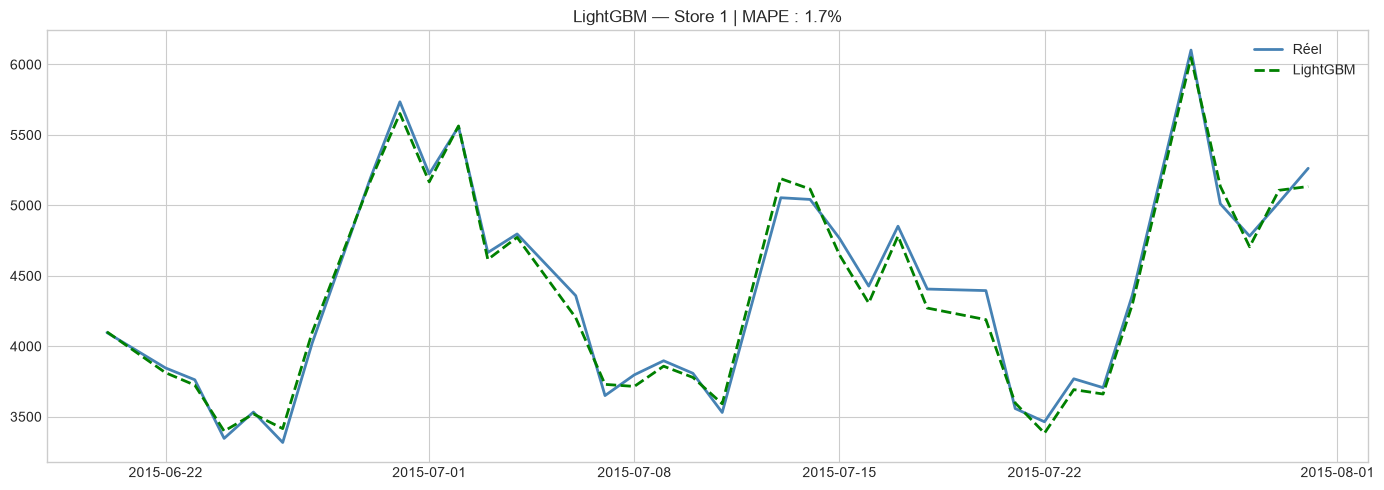

In [12]:
y_pred_lgb = np.expm1(model_lgb.predict(X_test))

mape_lgb = mean_absolute_percentage_error(y_test, y_pred_lgb) * 100
results['LightGBM'] = round(mape_lgb, 2)

print(f"LightGBM MAPE : {mape_lgb:.1f}%")
print(f"Prophet MAPE  : {results['Prophet']}%")
print(f"Baseline MAPE : 17.3%")

# Visualisation
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_lgb['Date'].values, y_test, 
        label='Réel', color='steelblue', linewidth=2)
ax.plot(test_lgb['Date'].values, y_pred_lgb, 
        label='LightGBM', color='green', linewidth=2, linestyle='--')
ax.set_title(f'LightGBM — Store {store_id} | MAPE : {mape_lgb:.1f}%')
ax.legend()
plt.tight_layout()
plt.show()

## Feature Importance

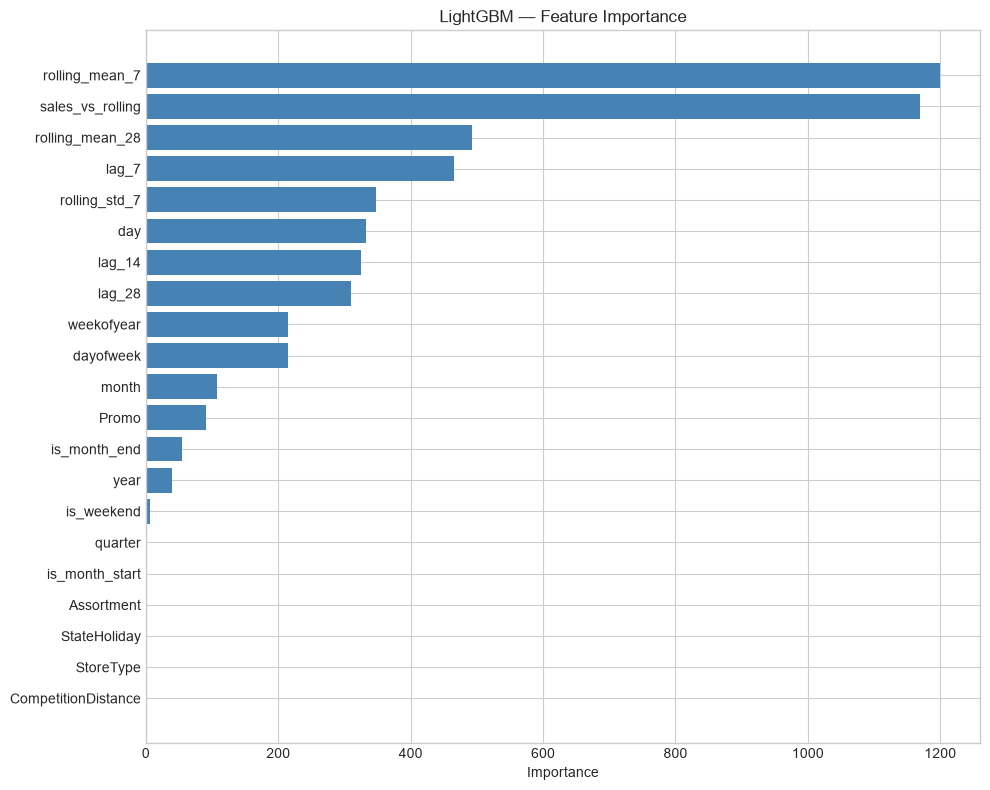


Top 5 features :
         feature  importance
   rolling_std_7         348
           lag_7         466
 rolling_mean_28         492
sales_vs_rolling        1169
  rolling_mean_7        1200


In [13]:
feat_imp = pd.DataFrame({
    'feature': FEATURES,
    'importance': model_lgb.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(feat_imp['feature'], feat_imp['importance'], color='steelblue')
ax.set_title('LightGBM — Feature Importance')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print("\nTop 5 features :")
print(feat_imp.tail(5)[['feature', 'importance']].to_string(index=False))

## LightGBM Results

- MAPE : 1.7% (vs 7.3% Prophet, vs 17.3% baseline)
- SC features (lags, rolling means) dominate the other ones
- `sales_vs_rolling`,  demand / recent trend ratio, is an integrated anomaly detection signal
- `Promo` does not come up as a top feature but is surely encoding into the moving averages. Importance is real as demonstrated during EDA (+38.8% lift)

**Décision** : LightGBM is the best model for this store. TFT to be evaluated for multi-store generalization.

# StatsForecast AutoARIMA & AutoETS

## Data Preparation

3 columns are expected:
- series ID (unique_id)
- date (ds)
- target (y)

In [14]:
df_sf = df_store[['Date', 'Sales']].rename(columns={
    'Date': 'ds',
    'Sales': 'y'
})
df_sf['unique_id'] = f'store_{store_id}'
df_sf['y'] = np.log1p(df_sf['y'])

print(f"Shape : {df_sf.shape}")
df_sf.tail(3)


Shape : (781, 3)


,ds,y,unique_id
2230,2015-07-29,8.472823,store_1
1115,2015-07-30,8.521384,store_1
0,2015-07-31,8.568646,store_1


## Train/test split

In [15]:
horizon = len(test_s)
print(f"Horizon : {horizon} days")

df_train_sf = df_sf[df_sf['ds'] <= cutoff].copy()
df_test_sf  = df_sf[df_sf['ds'] > cutoff].copy()

print(f"Train SF : {len(df_train_sf)} | Test SF : {len(df_test_sf)}")

Horizon : 36 days
Train SF : 745 | Test SF : 36


## Training

In [16]:
# Models
sf = StatsForecast(
    models=[AutoARIMA(season_length=7), AutoETS(season_length=7)],
    freq='D',
    n_jobs=-1,
)

sf.fit(df_train_sf)
print("StatsForecast trained ✓")

StatsForecast trained ✓


## Predictions

In [17]:
preds_sf = sf.predict(h=horizon)

# AutoARIMA
y_pred_arima = np.expm1(preds_sf['AutoARIMA'].values)
mape_arima = mean_absolute_percentage_error(y_test, y_pred_arima) * 100
results['AutoARIMA'] = round(mape_arima, 2)

# AutoETS
y_pred_ets = np.expm1(preds_sf['AutoETS'].values)
mape_ets = mean_absolute_percentage_error(y_test, y_pred_ets) * 100
results['AutoETS'] = round(mape_ets, 2)

print(f"AutoARIMA MAPE : {mape_arima:.1f}%")
print(f"AutoETS MAPE   : {mape_ets:.1f}%")

AutoARIMA MAPE : 15.7%
AutoETS MAPE   : 14.4%


## Visualization

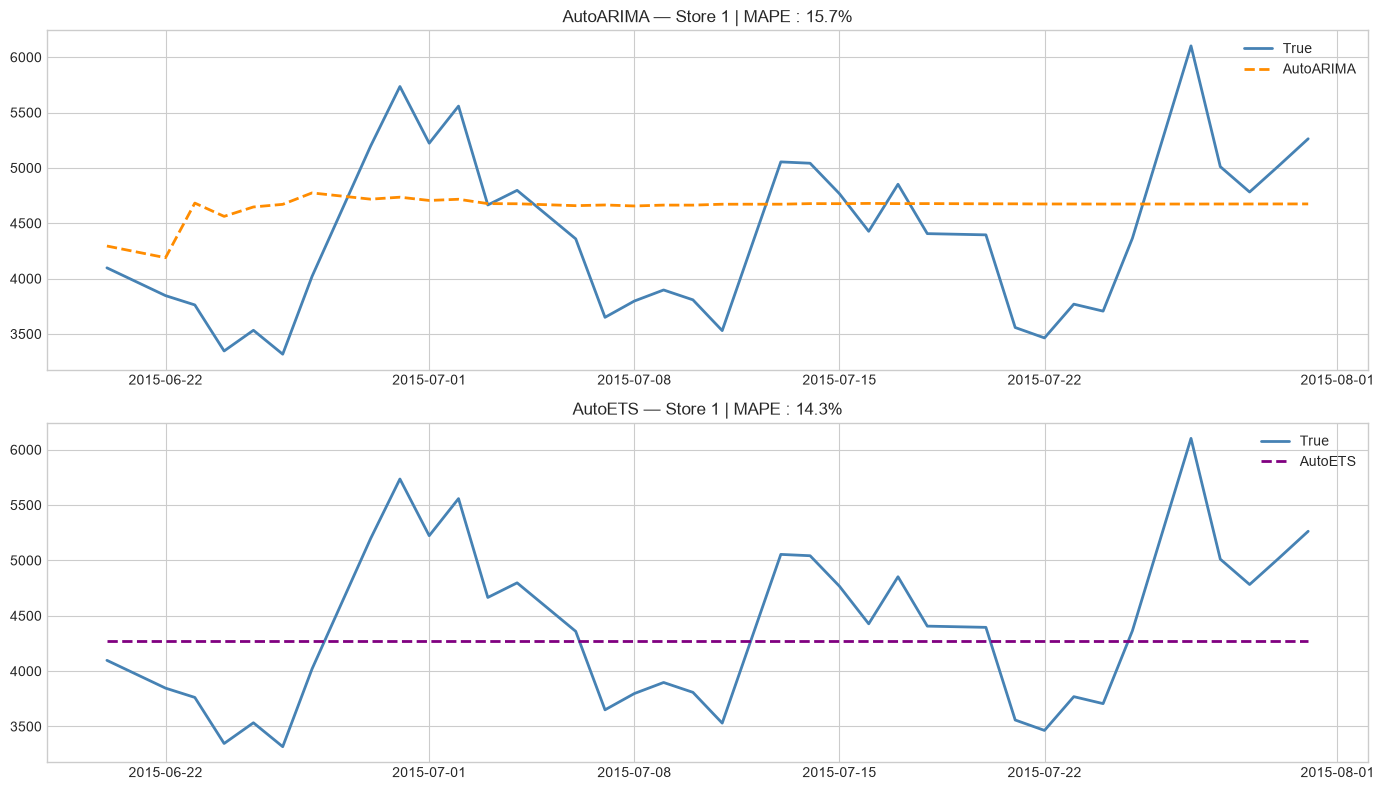

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for ax, y_pred, label, color in zip(
    axes,
    [y_pred_arima, y_pred_ets],
    ['AutoARIMA', 'AutoETS'],
    ['darkorange', 'purple']
):
    ax.plot(test_s['Date'].values, y_test,
            label='True', color='steelblue', linewidth=2)
    ax.plot(test_s['Date'].values, y_pred,
            label=label, color=color, linewidth=2, linestyle='--')
    ax.set_title(f'{label} — Store {store_id} | MAPE : {results[label]:.1f}%')
    ax.legend()

plt.tight_layout()
plt.show()

# Result Comparison

BENCHMARK FINAL — Store 1
   Modèle  MAPE (%)  vs Baseline (pts)
 LightGBM      1.68               15.6
  Prophet      7.33               10.0
  AutoETS     14.35                3.0
AutoARIMA     15.68                1.6
 Baseline     17.30                0.0


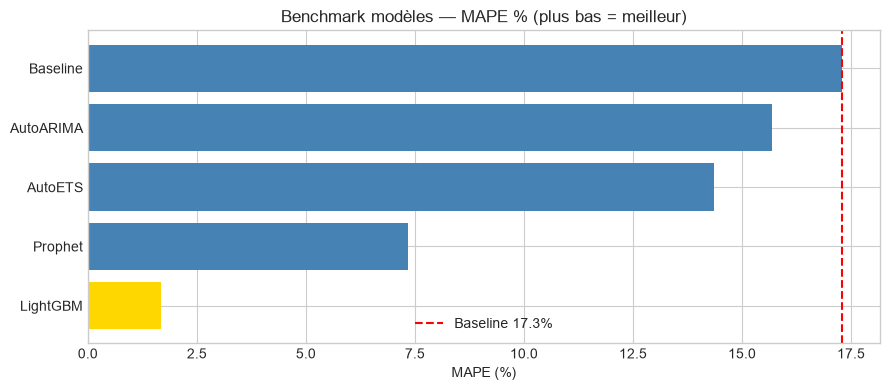

In [19]:
results['Baseline'] = 17.3

df_results = pd.DataFrame([
    {'Modèle': k, 'MAPE (%)': v, 'vs Baseline (pts)': round(17.3 - v, 1)}
    for k, v in results.items()
]).sort_values('MAPE (%)')

print("=" * 50)
print(f"BENCHMARK FINAL — Store {store_id}")
print("=" * 50)
print(df_results.to_string(index=False))
print("=" * 50)

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['gold' if v == df_results['MAPE (%)'].min()
          else 'steelblue' for v in df_results['MAPE (%)']]
ax.barh(df_results['Modèle'], df_results['MAPE (%)'], color=colors)
ax.axvline(x=17.3, color='red', linestyle='--', linewidth=1.5, label='Baseline 17.3%')
ax.set_title('Benchmark modèles — MAPE % (plus bas = meilleur)')
ax.set_xlabel('MAPE (%)')
ax.legend()
plt.tight_layout()
plt.show()


# Benchmark Conclusion - Store 1


**Key Learnings :**
1. The SC-related engineered features (lags, rolling means, demand/trend ratio) are the key performance drivers (top 5 features in lightGBM)
2. The statistical models (ARIMA, ETS) without exogeonous variables (promos) produce flat forecasts on this dataset. Promotions are not accounted for.
3. Prophet properly captures the seasonality and the promotion effects thanks to the external regressors.
4. Next step: generalized LightGBM for all stores and integrate to MLflow.